## Model Training

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso 
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
import pickle
%matplotlib inline

In [4]:
df = pd.read_csv('Algerian_forest_fires_dataset_cleaned.csv')

In [5]:
df.sample(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
138,17,6,2012,31,69,17,4.7,62.2,3.9,8.0,1.1,3.8,0.4,not fire,1
117,26,9,2012,31,54,11,0.0,82.0,6.0,16.3,2.5,6.2,1.7,not fire,0
90,30,8,2012,35,70,17,0.8,72.7,25.2,180.4,1.7,37.4,4.2,not fire,0
23,24,6,2012,32,66,17,0.0,85.9,11.2,55.8,5.6,14.9,7.5,fire,0
34,5,7,2012,33,66,14,0.0,85.9,7.6,27.9,4.8,9.1,4.9,fire,0


In [6]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [7]:
df.drop(['day', 'month', 'year'],inplace=True,axis=1)

In [8]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [9]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [10]:
## Encoding 
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),0,1)

In [11]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [12]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [13]:
## Independt and Dependent Features
x = df.drop('FWI',axis=1)
y = df['FWI']

In [14]:
x , y

(     Temperature  RH  Ws  Rain  FFMC   DMC    DC  ISI   BUI  Classes  Region
 0             29  57  18   0.0  65.7   3.4   7.6  1.3   3.4        0       0
 1             29  61  13   1.3  64.4   4.1   7.6  1.0   3.9        0       0
 2             26  82  22  13.1  47.1   2.5   7.1  0.3   2.7        0       0
 3             25  89  13   2.5  28.6   1.3   6.9  0.0   1.7        0       0
 4             27  77  16   0.0  64.8   3.0  14.2  1.2   3.9        0       0
 ..           ...  ..  ..   ...   ...   ...   ...  ...   ...      ...     ...
 238           30  65  14   0.0  85.4  16.0  44.5  4.5  16.9        1       1
 239           28  87  15   4.4  41.1   6.5   8.0  0.1   6.2        0       1
 240           27  87  29   0.5  45.9   3.5   7.9  0.4   3.4        0       1
 241           24  54  18   0.1  79.7   4.3  15.2  1.7   5.1        0       1
 242           24  64  15   0.2  67.3   3.8  16.5  1.2   4.8        0       1
 
 [243 rows x 11 columns],
 0      0.5
 1      0.4
 2      0.1


In [15]:
# Train test spilt 
x_train , x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=43)

In [16]:
x_train.shape

(194, 11)

In [17]:
x_test.shape

(49, 11)

In [18]:
## Feature selection on correlation
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.660860,-0.284392,-0.370953,0.709540,0.502166,0.399657,0.629599,0.480703,0.567314,0.298520
RH,-0.660860,1.000000,0.271578,0.263457,-0.670776,-0.435139,-0.249433,-0.716899,-0.379442,-0.488679,-0.436176
Ws,-0.284392,0.271578,1.000000,0.138923,-0.192611,0.008522,0.071632,0.009793,0.032604,-0.100426,-0.189723
Rain,-0.370953,0.263457,0.138923,1.000000,-0.585035,-0.286036,-0.290784,-0.350701,-0.295229,-0.399343,-0.075552
FFMC,0.709540,-0.670776,-0.192611,-0.585035,1.000000,0.597062,0.498240,0.739795,0.582416,0.783134,0.241582
DMC,0.502166,-0.435139,0.008522,-0.286036,0.597062,1.000000,0.875032,0.693659,0.983867,0.584878,0.216300
DC,0.399657,-0.249433,0.071632,-0.290784,0.498240,0.875032,1.000000,0.508356,0.945505,0.498027,-0.067019
ISI,0.629599,-0.716899,0.009793,-0.350701,0.739795,0.693659,0.508356,1.000000,0.647922,0.729186,0.295988
BUI,0.480703,-0.379442,0.032604,-0.295229,0.582416,0.983867,0.945505,0.647922,1.000000,0.574590,0.115314
Classes,0.567314,-0.488679,-0.100426,-0.399343,0.783134,0.584878,0.498027,0.729186,0.574590,1.000000,0.207894


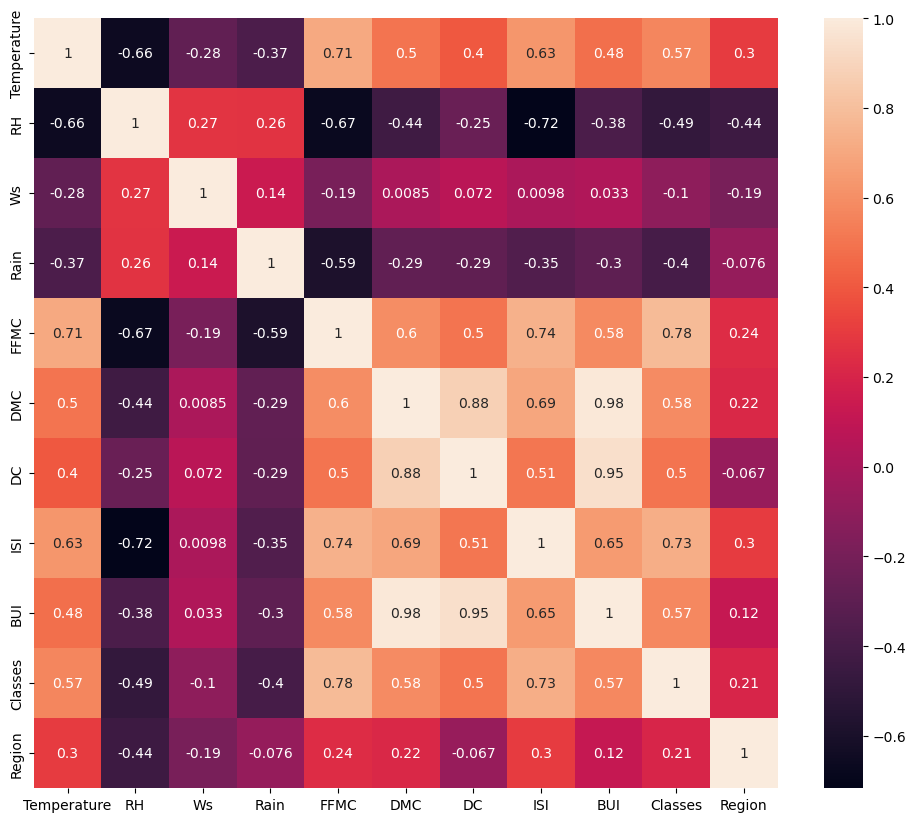

In [19]:
## Check for Multicolinearity
plt.figure(figsize=(12,10))
corr = x_train.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [20]:
def correlation(dataset,threhold):
    col_corr = set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threhold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [21]:
## Threshold - Domain Experts
corr_features = correlation(x_train,0.85)

In [22]:
## Drop these features when correlation is more than 0.85
x_train.drop(corr_features,axis=1,inplace=True)
x_test.drop(corr_features,axis=1,inplace=True)

In [23]:
x_train.shape , x_test.shape

((194, 9), (49, 9))

## Feature scaling and standardization

In [24]:
x_train

,Temperature,RH,Ws,Rain,FFMC,DMC,ISI,Classes,Region
67,32,69,16,0.0,86.5,15.5,5.5,1,0
207,33,37,16,0.0,92.2,61.3,13.1,1,1
101,33,73,12,1.8,59.9,2.2,0.7,0,0
220,30,88,14,0.0,82.5,6.6,3.0,1,1
185,38,35,15,0.0,93.8,23.0,15.7,1,1
...,...,...,...,...,...,...,...,...,...
58,32,73,15,0.0,86.6,26.7,5.6,1,0
21,31,67,17,0.1,79.1,7.0,2.4,0,0
49,33,65,15,0.1,81.4,12.3,2.8,1,0
64,34,69,13,0.0,85.0,8.2,4.0,1,0


In [25]:
scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

In [26]:
x_train_scaled

array([[-0.06261261,  0.51369253,  0.19527625, ...,  0.11521416,
         0.8288284 , -1.01036297],
       [ 0.2073173 , -1.64249625,  0.19527625, ...,  1.89211544,
         0.8288284 ,  0.98974332],
       [ 0.2073173 ,  0.78321612, -1.18230896, ..., -1.00703927,
        -1.20652236, -1.01036297],
       ...,
       [ 0.2073173 ,  0.24416893, -0.14912005, ..., -0.5160534 ,
         0.8288284 , -1.01036297],
       [ 0.47724721,  0.51369253, -0.83791266, ..., -0.23549004,
         0.8288284 , -1.01036297],
       [-0.06261261, -0.09273557,  0.88406886, ..., -0.65633508,
        -1.20652236, -1.01036297]])

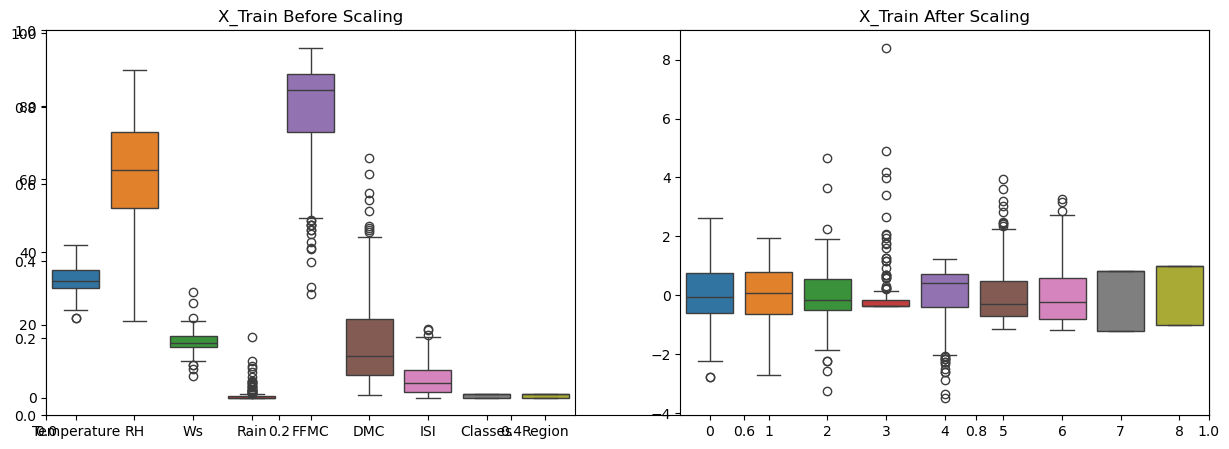

In [27]:
## Box plot to understand effect of standard scalar 
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=x_train)
plt.title('X_Train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(data=x_train_scaled)
plt.title('X_Train After Scaling')
plt.show()

## Linear Regression Model



In [28]:
linear_reg = LinearRegression()

In [29]:
x_test , x_train_scaled

(     Temperature  RH  Ws  Rain  FFMC   DMC   ISI  Classes  Region
 59            31  79  15   0.0  85.4  28.5   4.7        1       0
 228           33  26  13   0.0  93.9  21.2  14.2        1       1
 78            36  54  18   0.0  89.4  20.0   9.7        1       0
 222           29  74  15   1.1  59.5   4.7   0.8        0       1
 76            36  61  18   0.3  80.2  11.7   2.8        1       0
 148           36  55  15   0.0  89.1  20.9   8.0        1       1
 103           29  88  13   0.0  71.0   2.6   1.2        0       0
 88            34  64  16   0.0  89.4  50.2   7.3        1       0
 213           29  86  16   0.0  37.9   0.9   0.1        0       1
 238           30  65  14   0.0  85.4  16.0   4.5        1       1
 212           30  59  19   0.0  89.1  27.8   9.8        1       1
 17            31  78  14   0.3  56.9   1.9   0.7        0       0
 29            33  50  14   0.0  88.7  22.9   7.2        1       0
 183           40  34  14   0.0  93.3  10.8  13.8        1    

In [30]:
linear_reg.fit(x_train_scaled,y_train)
y_pred = linear_reg.predict(x_test_scaled)

In [31]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

Mean Squared Error:-  1.0689748425551655
Mean Absolute Error:-  0.6887976522689955
Root Mean Squared Error:-  1.033912395977128
R2_Score:-  0.9678122189632756


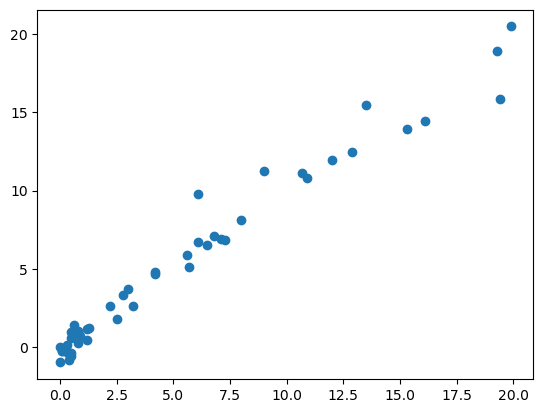

In [32]:
print('Mean Squared Error:- ' , mse)
print('Mean Absolute Error:- ' , mae)
print('Root Mean Squared Error:- ' , rmse)
print('R2_Score:- ' , r2)
plt.scatter(y_test,y_pred)
plt.show()

## Lasso Regression Model

Mean Squared Error:-  2.040241676867474
Mean Absolute Error:-  1.0759106934758922
Root Mean Squared Error:-  1.4283702870290582
R2_Score:-  0.9385665127534368


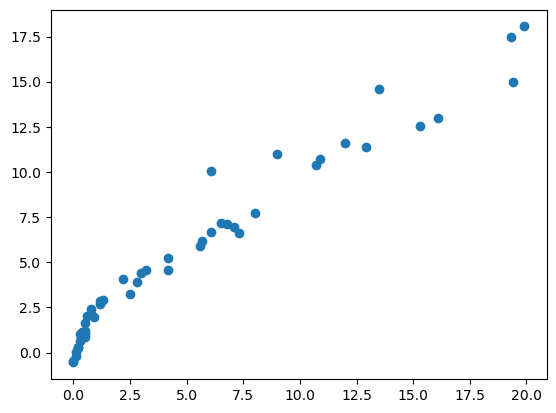

In [33]:
lasso_reg = Lasso()
lasso_reg.fit(x_train_scaled,y_train)
y_pred = lasso_reg.predict(x_test_scaled)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:- ' , mse)
print('Mean Absolute Error:- ' , mae)
print('Root Mean Squared Error:- ' , rmse)
print('R2_Score:- ' , r2)
plt.scatter(y_test,y_pred)
plt.show()

## Crosss Validation Lasso

In [34]:
lasso_cv = LassoCV(cv=5)
lasso_cv.fit(x_train_scaled,y_train)

LassoCV(cv=5)

In [35]:
lasso_cv.alpha_

0.03301144862919499

In [36]:
lasso_cv.alphas_

array([7.11210101, 6.6327692 , 6.18574276, 5.7688444 , 5.3800436 ,
       5.01744666, 4.67928755, 4.36391923, 4.06980568, 3.7955144 ,
       3.53970943, 3.30114486, 3.07865875, 2.87116745, 2.67766038,
       2.49719503, 2.32889244, 2.17193288, 2.02555188, 1.88903646,
       1.76172173, 1.64298758, 1.53225571, 1.42898681, 1.33267788,
       1.24285985, 1.15909526, 1.08097611, 1.00812194, 0.9401779 ,
       0.87681305, 0.81771879, 0.76260728, 0.7112101 , 0.66327692,
       0.61857428, 0.57688444, 0.53800436, 0.50174467, 0.46792876,
       0.43639192, 0.40698057, 0.37955144, 0.35397094, 0.33011449,
       0.30786587, 0.28711675, 0.26776604, 0.2497195 , 0.23288924,
       0.21719329, 0.20255519, 0.18890365, 0.17617217, 0.16429876,
       0.15322557, 0.14289868, 0.13326779, 0.12428598, 0.11590953,
       0.10809761, 0.10081219, 0.09401779, 0.08768131, 0.08177188,
       0.07626073, 0.07112101, 0.06632769, 0.06185743, 0.05768844,
       0.05380044, 0.05017447, 0.04679288, 0.04363919, 0.04069

In [37]:
lasso_cv.mse_path_

array([[66.95089153, 58.51310949, 67.80647594, 48.94639874, 47.02838041],
       [64.30346201, 52.68609581, 63.83147004, 43.70619337, 42.479536  ],
       [56.23308291, 47.56801173, 58.88262678, 39.20322516, 38.50555207],
       [49.20489118, 43.0698913 , 52.86023744, 34.94652485, 34.99784106],
       [43.08362839, 39.11412917, 46.42107922, 30.63935839, 30.78230542],
       [37.75186309, 34.45524588, 40.79995081, 26.9255318 , 27.10425307],
       [33.10712193, 29.93301222, 35.89175173, 23.72637337, 23.89405081],
       [29.06062727, 26.01731926, 31.60478733, 20.9724493 , 21.09151663],
       [25.53481097, 22.62923755, 27.85942207, 18.60384367, 18.64425659],
       [22.46228422, 19.69834718, 24.58624323, 16.56857446, 16.5062529 ],
       [19.78440672, 17.16402712, 21.72487725, 14.82113987, 14.63863985],
       [17.4500368 , 14.97362496, 19.22251889, 13.32330134, 13.00637008],
       [15.41500687, 13.0814136 , 17.0334001 , 12.04069371, 11.57932289],
       [13.64053949, 11.44729105, 15.1

Mean Squared Error:-  1.0512129288368302
Mean Absolute Error:-  0.6665674999474245
Root Mean Squared Error:-  1.0252867544432778
R2_Score:-  0.9683470459459129


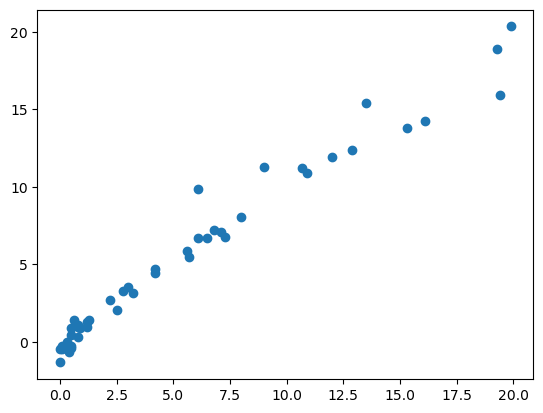

In [38]:
y_pred = lasso_cv.predict(x_test_scaled)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:- ' , mse)
print('Mean Absolute Error:- ' , mae)
print('Root Mean Squared Error:- ' , rmse)
print('R2_Score:- ' , r2)
plt.scatter(y_test,y_pred)
plt.show()

## Ridge Regression Model

Mean Squared Error:-  1.0864302141980995
Mean Absolute Error:-  0.7016925424650385
Root Mean Squared Error:-  1.0423196314941494
R2_Score:-  0.9672866222345309


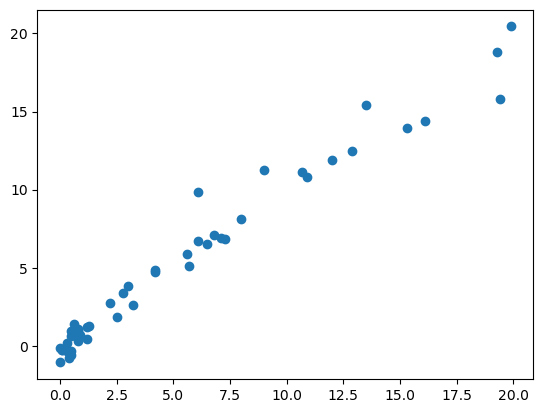

In [39]:
ridge_reg = Ridge()
ridge_reg.fit(x_train_scaled,y_train)
y_pred = ridge_reg.predict(x_test_scaled)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:- ' , mse)
print('Mean Absolute Error:- ' , mae)
print('Root Mean Squared Error:- ' , rmse)
print('R2_Score:- ' , r2)
plt.scatter(y_test,y_pred)
plt.show()

## Cross Validation Ridge

Mean Squared Error:-  1.0864302141980995
Mean Absolute Error:-  0.7016925424650385
Root Mean Squared Error:-  1.0423196314941494
R2_Score:-  0.9672866222345309


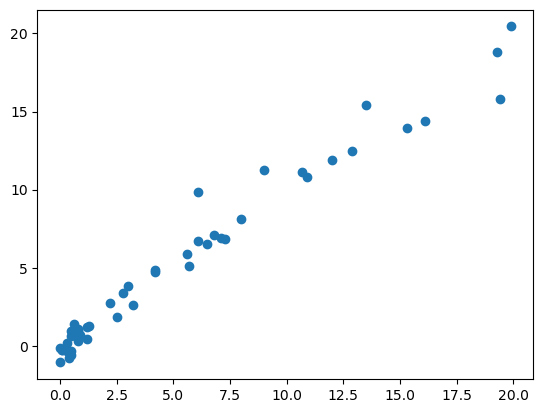

In [40]:
ridge_cv = RidgeCV(cv=5)
ridge_cv.fit(x_train_scaled,y_train)
y_pred = ridge_cv.predict(x_test_scaled)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:- ' , mse)
print('Mean Absolute Error:- ' , mae)
print('Root Mean Squared Error:- ' , rmse)
print('R2_Score:- ' , r2)
plt.scatter(y_test,y_pred)
plt.show()

In [41]:
ridge_cv.alphas

(0.1, 1.0, 10.0)

## Elastic Net Regression Model

Mean Squared Error:-  3.9609871145652598
Mean Absolute Error:-  1.572251156888777
Root Mean Squared Error:-  1.9902228806254991
R2_Score:-  0.8807311633001935


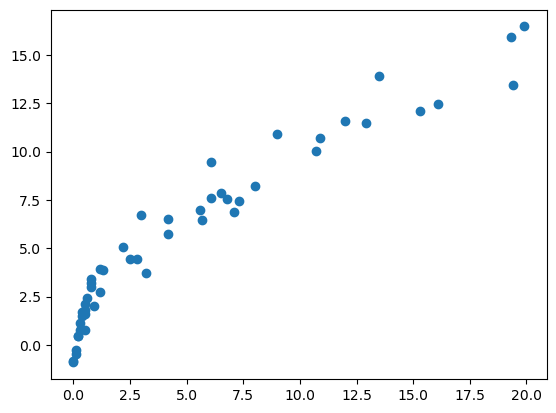

In [42]:
elastci_net_reg = ElasticNet()
elastci_net_reg.fit(x_train_scaled,y_train)
y_pred = elastci_net_reg.predict(x_test_scaled)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:- ' , mse)
print('Mean Absolute Error:- ' , mae)
print('Root Mean Squared Error:- ' , rmse)
print('R2_Score:- ' , r2)
plt.scatter(y_test,y_pred)
plt.show()

## Cross Validation ElasticNet

Mean Squared Error:-  1.111359839126876
Mean Absolute Error:-  0.7202816295158778
Root Mean Squared Error:-  1.0542105288446306
R2_Score:-  0.9665359691072626


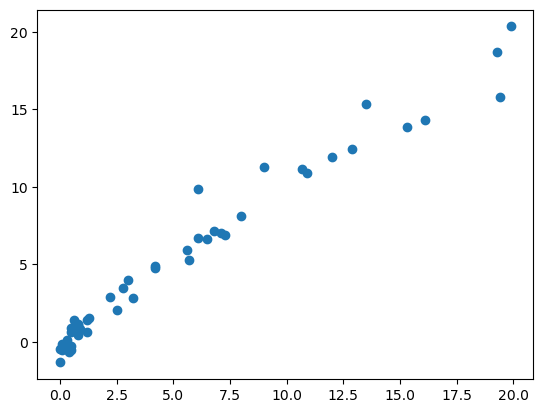

In [43]:
elastci_net_cv = ElasticNetCV(cv=5)
elastci_net_cv.fit(x_train_scaled,y_train)
y_pred = elastci_net_cv.predict(x_test_scaled)
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)
print('Mean Squared Error:- ' , mse)
print('Mean Absolute Error:- ' , mae)
print('Root Mean Squared Error:- ' , rmse)
print('R2_Score:- ' , r2)
plt.scatter(y_test,y_pred)
plt.show()

## Pickling the files


In [44]:
pickle.dump(scalar,open('scalar.pkl','wb'))
pickle.dump(ridge_reg,open('ridge.pkl','wb'))